# Proyek Analisis Data: E-Commerce Public Dataset
- **Nama:** Muhammad Zaky Naufal
- **Email:** AIC012B6Y0029@student.devacademy.id
- **ID Dicoding:** AIC012B6Y0029

## Menentukan Pertanyaan Bisnis

- **Pertanyaan 1:** Kategori produk apa yang menghasilkan total penjualan tertinggi dan terendah berdasarkan nilai transaksi pada periode 2016–2018?
- **Pertanyaan 2:**  Bagaimana tren total penjualan e-commerce setiap bulan selama periode 2016–2018?


## Import Semua Packages/Library yang Digunakan

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Data Wrangling

### Gathering Data

#### Load orders_df

In [52]:
# Memuat tabel orders
orders_df = pd.read_csv("orders_dataset.csv")
orders_df.head()


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


#### Load products_df

In [53]:
# Memuat tabel products
products_df = pd.read_csv("products_dataset.csv")
products_df.head()



,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


Load order_items_df

In [54]:
# Memuat tabel order items
order_items_df = pd.read_csv("order_items_dataset.csv")
order_items_df.head()


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


Load translation_df

In [55]:
# Memuat tabel product category name
translation_df = pd.read_csv("product_category_name_translation.csv")
translation_df.head()



,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


**Insight:**
- Pada tahap gathering data ini kita load semua data yang ada pada csv yang dibuat menjadi dataframe.
- Fungsi dari gathering data adalah untuk mengumpulkan semua data yang dibutuhkan.

### Assessing Data

#### Identifikasi Data orders_df

In [56]:
# Menilai Data orders_df
orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [57]:
#  Memeriksa Parameter Statistik
orders_df.describe()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [58]:
# Memeriksa Missing Value
orders_df.isna().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [59]:
# Memeriksa Duplikat Data
print("Jumlah duplikasi: ", orders_df.duplicated().sum())

Jumlah duplikasi:  0


#### Identifikasi Data products_df

In [60]:
# Menilai Data products
products_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [61]:
#  Memeriksa Parameter Statistik
products_df.describe()

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


In [62]:
# Memeriksa Missing Value
products_df.isna().sum()

,0
product_id,0
product_category_name,610
product_name_lenght,610
product_description_lenght,610
product_photos_qty,610
product_weight_g,2
product_length_cm,2
product_height_cm,2
product_width_cm,2


In [63]:
# Memeriksa Duplikat Data
print("Jumlah duplikasi: ", products_df.duplicated().sum())

Jumlah duplikasi:  0


#### Identifikasi Data order_items_df

In [64]:
# Menilai Order Items
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [65]:
#  Memeriksa Parameter Statistik
order_items_df.describe()

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


In [66]:
# Memeriksa Missing Value
order_items_df.isna().sum()

,0
order_id,0
order_item_id,0
product_id,0
seller_id,0
shipping_limit_date,0
price,0
freight_value,0


In [67]:
# Memeriksa Duplikat Data
print("Jumlah duplikasi: ", order_items_df.duplicated().sum())

Jumlah duplikasi:  0


#### Identifikasi Data translation_df

In [68]:
# Menilai Order Items
translation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [69]:
#  Memeriksa Parameter Statistik
translation_df.describe()

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


In [70]:
# Memeriksa Missing Value
translation_df.isna().sum()

,0
product_category_name,0
product_category_name_english,0


In [71]:
# Memeriksa Duplikat Data
print("Jumlah duplikasi: ", translation_df.duplicated().sum())

Jumlah duplikasi:  0


#### **Steps to Take:**
- Mengubah tipe data timestamp pada orders_df menjadi datetime.
- Mengubah tipe data timestamp pada order_items_df menjadi datetime.
- Menghapus missing value pada products_df.
- Menggabungkan dataset `product_category_name_translation` ke dataset `product`untuk menerjemahkan nama kategori produk dari bahasa Portugis ke bahasa Inggris agar lebih mudah dianalisis.

#### **Insight:** (Opsional)
- Dataset orders_df memiliki missing value pada beberapa kolom delivery, namun masih relevan dengan status transaksi seperti shipped dan invoiced.
- Dataset products_df memiliki missing value pada informasi kategori produk sehingga perlu dilakukan cleaning.
- Dataset order_items_df dan translation_df tergolong bersih karena tidak ditemukan missing value maupun duplicate data.

### Cleaning Data

#### Mengubah tipe data timestamp pada orders_df menjadi datetime

In [72]:


datetime_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for column in datetime_columns:
    orders_df[column] = pd.to_datetime(orders_df[column])


orders_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


#### Mengubah tipe data timestamp pada order_items_df menjadi datetime

In [73]:
order_items_df["shipping_limit_date"] = pd.to_datetime(
    order_items_df["shipping_limit_date"]
)

order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


#### Menggabungkan dataset `product_category_name_translation` ke dataset `product`untuk menerjemahkan nama kategori produk dari bahasa Portugis ke bahasa Inggris agar lebih mudah dianalisis.

In [74]:
products_df = pd.merge(
    products_df,
    translation_df,
    on="product_category_name",
    how="left"
)

products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


#### Menghapus missing value pada products_df.

In [75]:
 # menampilkan semua baris data yang memiliki missing value
products_df[products_df.product_category_name.isna()]

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0,NaN
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0,NaN
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0,NaN
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0,NaN
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0,NaN
...,...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0,NaN
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0,NaN
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0,NaN
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0,NaN


In [76]:
products_df.dropna(inplace=True)

products_df.isna().sum()

,0
product_id,0
product_category_name,0
product_name_lenght,0
product_description_lenght,0
product_photos_qty,0
product_weight_g,0
product_length_cm,0
product_height_cm,0
product_width_cm,0
product_category_name_english,0


#### **Insight:** (Opsional)
- Kolom timestamp pada orders_df dan order_items_df berhasil diubah menjadi format datetime sehingga mempermudah analisis berbasis waktu.
- Missing value pada products_df berhasil dibersihkan sehingga dataset lebih siap digunakan untuk proses analisis dan visualisasi.

## Exploratory Data Analysis (EDA)

### Eksplorasi Data orders_df

In [77]:
order_status_percent = ( orders_df["order_status"] .value_counts(normalize=True)  * 100)
order_status_percent

,proportion
order_status,
delivered,97.020344
shipped,1.113223
canceled,0.628513
unavailable,0.612423
invoiced,0.315765
processing,0.302692
created,0.005028
approved,0.002011


Berdasarkan hasil eksplorasi, mayoritas transaksi memiliki status delivered dengan persentase mencapai **sekitar 97%**. Hal ini menunjukkan bahwa sebagian besar proses transaksi pada platform e-commerce berhasil diselesaikan hingga produk diterima pelanggan.

,delivery_time
count,96476.000000
mean,12.094086
std,9.551746
min,0.000000
25%,6.000000
50%,10.000000
75%,15.000000
max,209.000000


<Axes: >

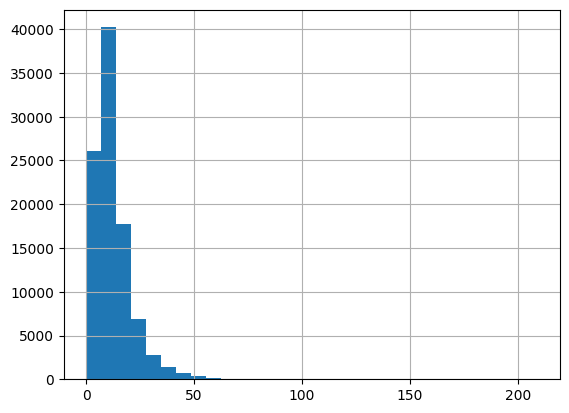

In [78]:
orders_df["delivery_time"] = (
orders_df["order_delivered_customer_date"]
    - orders_df["order_purchase_timestamp"]
).dt.days

display(orders_df["delivery_time"].describe())
display(orders_df["delivery_time"].hist(bins=30))

Kolom `delivery_time` dibuat dengan mengurangkan `order_delivered_customer_date` dengan `order_purchase_timestamp` untuk mengetahui lama waktu yang dibutuhkan sejak pelanggan melakukan checkout hingga pesanan diterima oleh pelanggan.

Berdasarkan hasil eksplorasi, rata-rata waktu pengiriman berada pada angka 12 hari dengan median sebesar 10 hari. Sebagian besar pesanan berhasil dikirim dalam rentang waktu 6 hingga 15 hari. Namun, terdapat beberapa pesanan dengan waktu pengiriman yang sangat lama hingga mencapai 209 hari, yang menunjukkan adanya sejumlah pengiriman yang memerlukan waktu jauh lebih lama dibandingkan mayoritas transaksi. Distribusi histogram juga menunjukkan bahwa mayoritas pengiriman terkonsentrasi pada waktu pengiriman yang relatif singkat dengan distribusi yang condong ke kanan (*right-skewed*).

### Eksplorasi Data products_df

In [79]:
products_df["product_category_name_english"].value_counts().head(10)

,count
product_category_name_english,
bed_bath_table,3029
sports_leisure,2867
furniture_decor,2657
health_beauty,2444
housewares,2335
auto,1900
computers_accessories,1639
toys,1411
watches_gifts,1329


Berdasarkan hasil eksplorasi, kategori produk `bed_bath_table` menjadi kategori dengan jumlah produk terbanyak, yaitu sebanyak 3029 produk, diikuti oleh `sports_leisure` sebanyak 2867 produk dan `furniture_decor` sebanyak 2657 produk. Sementara itu, kategori seperti `telephony` dan `watches_gifts` memiliki jumlah produk yang relatif lebih sedikit dibandingkan kategori teratas.

Hal ini menunjukkan bahwa platform e-commerce memiliki variasi kategori produk yang cukup beragam, dengan dominasi produk pada kategori kebutuhan rumah tangga, olahraga, dan dekorasi.

,product_weight_g
count,32327.000000
mean,2276.960807
std,4279.734063
min,0.000000
25%,300.000000
50%,700.000000
75%,1900.000000
max,40425.000000


<Axes: >

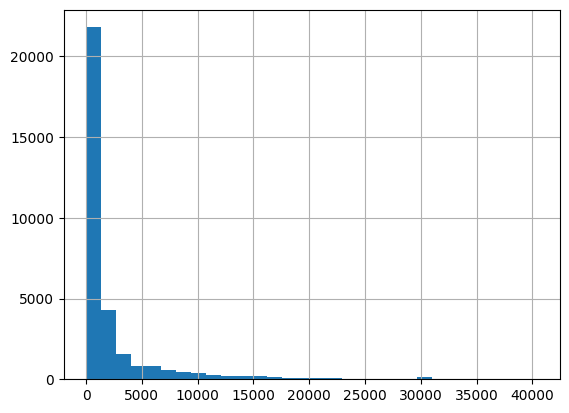

In [80]:
display(products_df["product_weight_g"].describe())
display(products_df["product_weight_g"].hist(bins=30))

Berdasarkan hasil eksplorasi, rata-rata berat produk berada pada angka sekitar 2276 gram dengan median sebesar 700 gram. Hal ini menunjukkan bahwa sebagian besar produk memiliki berat yang relatif ringan hingga menengah. Distribusi histogram juga memperlihatkan bahwa mayoritas produk terkonsentrasi pada berat rendah, sementara hanya sebagian kecil produk yang memiliki berat sangat besar hingga mencapai 40425 gram.

Distribusi data terlihat condong ke kanan (right-skewed), yang menandakan adanya beberapa produk dengan berat ekstrem dibandingkan mayoritas produk lainnya.

### Eksplorasi Data order_items_df

,total_price
count,112650.000000
mean,140.644059
std,190.724394
min,6.080000
25%,55.220000
50%,92.320000
75%,157.937500
max,6929.310000


<Axes: >

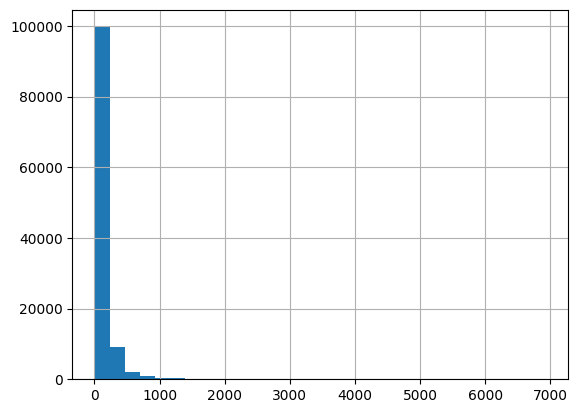

In [81]:
order_items_df["total_price"] = ( order_items_df["price"] + order_items_df["freight_value"])
display(order_items_df["total_price"].describe())
display(order_items_df["total_price"].hist(bins=30))

Kolom `total_price` dibuat dengan menjumlahkan price dan freight_value karena total biaya yang dibayarkan pelanggan tidak hanya berasal dari harga produk, tetapi juga mencakup biaya pengiriman (ongkir).

Berdasarkan hasil eksplorasi, rata-rata nilai transaksi berada pada angka 140.64 dengan median sebesar 92.32. Hal ini menunjukkan bahwa **sebagian besar transaksi cenderung berada pada nilai rendah hingga menengah.** Selain itu, nilai maksimum transaksi mencapai 6929.31, jauh lebih tinggi dibandingkan nilai kuartil ketiga (157.94), yang mengindikasikan adanya sejumlah transaksi bernilai sangat besar. Distribusi histogram juga menunjukkan bahwa data condong ke kanan (*right-skewed*), di mana mayoritas transaksi terkonsentrasi pada rentang nilai kecil.

,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


,price,freight_value
price,1.000000,0.414204
freight_value,0.414204,1.000000


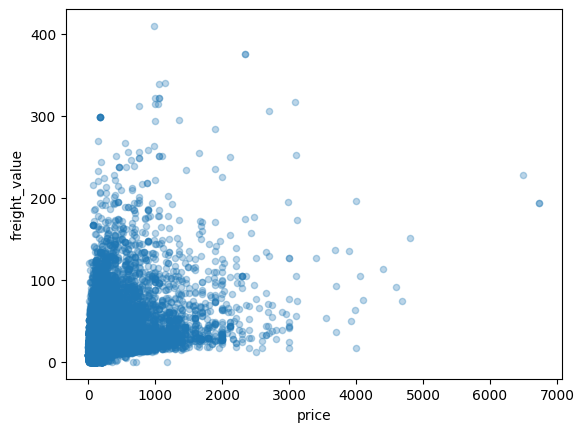

In [82]:
display(order_items_df[["price", "freight_value"]].describe())

order_items_df.plot(
    kind="scatter",
    x="price",
    y="freight_value",
    alpha=0.3
)

display(order_items_df[["price", "freight_value"]].corr())

Berdasarkan hasil eksplorasi, nilai korelasi antara `price` dan `freight_value` sebesar **0.41**, yang menunjukkan adanya hubungan positif sedang antara harga produk dan biaya pengiriman. Hal ini mengindikasikan bahwa produk dengan harga lebih tinggi cenderung memiliki ongkir yang lebih besar, meskipun hubungan tersebut tidak terlalu kuat.

Visualisasi scatter plot juga menunjukkan bahwa sebagian besar transaksi terkonsentrasi pada rentang harga dan ongkir yang rendah. Selain itu, terdapat beberapa transaksi dengan harga produk maupun ongkir yang sangat tinggi dibanding mayoritas data lainnya.

### Eksplorasi Data orders_df dan order_items_df

In [83]:
#Menggabungkan kedua dataset
orders_items_df = pd.merge(
    orders_df,
    order_items_df,
    on="order_id",
    how="inner"
)

orders_items_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,8.0,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,13.0,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,9.0,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,13.0,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2.0,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,28.62


In [84]:
status_freight = (
    orders_items_df
    .groupby("order_status")["freight_value"]
    .mean()
    .sort_values(ascending=False)
)

status_freight

,freight_value
order_status,
processing,25.083725
shipped,22.280084
invoiced,20.786574
delivered,19.948598
canceled,19.650277
unavailable,18.971429
approved,10.493333


Fitur `order_status` dan `freight_value` digabungkan untuk melihat bagaimana rata-rata biaya pengiriman pada setiap status pesanan. Analisis ini dilakukan karena biaya pengiriman dapat menjadi salah satu faktor yang memengaruhi proses dan keberhasilan transaksi.

Berdasarkan hasil eksplorasi, status processing memiliki rata-rata freight_value tertinggi sebesar 25.08, diikuti oleh shipped sebesar 22.28 dan delivered sebesar 19.95. Secara umum, rata-rata biaya pengiriman pada tiap status pesanan tidak menunjukkan perbedaan yang terlalu jauh.

In [85]:
orders_items_df["purchase_month"] = (
    orders_items_df["order_purchase_timestamp"].dt.month
)

monthly_freight = (
    orders_items_df
    .groupby("purchase_month")["freight_value"]
    .mean()
    .sort_values(ascending=False)
)

monthly_freight

,freight_value
purchase_month,
7,21.545168
6,21.337327
3,20.470506
4,20.221906
8,19.974919
9,19.864835
10,19.770294
11,19.489025
5,19.350298


Fitur `order_purchase_timestamp` dan `freight_value` digabungkan untuk melihat rata-rata biaya pengiriman pada setiap bulan transaksi. Analisis ini dilakukan untuk memahami bagaimana distribusi biaya pengiriman selama periode transaksi berlangsung.

Berdasarkan hasil eksplorasi, rata-rata `freight_value` pada setiap bulan berada pada rentang yang relatif mirip, yaitu sekitar 18 hingga 21. Bulan Juli memiliki rata-rata biaya pengiriman tertinggi sebesar 21.55, sedangkan Februari memiliki rata-rata terendah sebesar 18.88. Perbedaan antar bulan tidak terlalu signifikan, sehingga dapat diindikasikan bahwa biaya pengiriman **cenderung stabil sepanjang tahun transaksi.**

### Eksplorasi Data products_df dan order_items_df

In [86]:
# Menggabungkan kedua dataset
products_items_df = pd.merge(
    products_df,
    order_items_df,
    on="product_id",
    how="inner"
)

products_items_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,2018-04-30 17:33:54,10.91,7.39,18.30
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,2018-02-06 19:11:15,248.00,17.99,265.99
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,2018-07-11 21:30:20,79.80,7.82,87.62
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,2018-08-07 09:10:13,112.30,9.54,121.84
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,2018-04-17 01:30:23,37.90,8.29,46.19


In [87]:
category_price = (
    products_items_df
    .groupby("product_category_name_english")["price"]
    .mean()
    .sort_values(ascending=False)
)

category_price.head(10)

,price
product_category_name_english,
computers,1098.340542
small_appliances_home_oven_and_coffee,624.285658
home_appliances_2,476.124958
agro_industry_and_commerce,342.124858
musical_instruments,281.616000
small_appliances,280.778468
fixed_telephony,225.693182
construction_tools_safety,208.992371
watches_gifts,201.135984


Fitur `product_category_name` dan `price` digabungkan untuk melihat rata-rata harga produk pada setiap kategori. Analisis ini dilakukan untuk memahami karakteristik harga pada masing-masing kategori produk yang dijual di platform e-commerce.

Berdasarkan hasil eksplorasi, kategori `computers` memiliki rata-rata harga tertinggi sebesar 1098.34, diikuti oleh `small_appliances_home_oven_and_coffee	` sebesar 624.29 dan `home_appliances_2` sebesar 476.12. Sementara itu, beberapa kategori lain seperti `watches_gifts` dan `construction_tools_safety` memiliki rata-rata harga yang relatif lebih rendah dibandingkan kategori teratas. Hal ini menunjukkan bahwa setiap kategori produk memiliki karakteristik harga yang berbeda-beda.

,product_weight_g,freight_value
product_weight_g,1.000000,0.611332
freight_value,0.611332,1.000000


<Axes: xlabel='product_weight_g', ylabel='freight_value'>

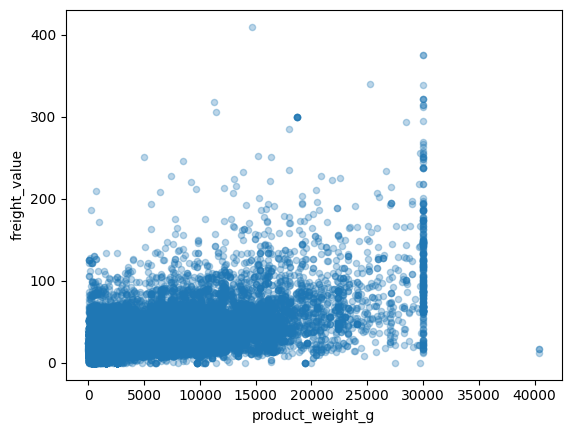

In [88]:
display(products_items_df[
    ["product_weight_g", "freight_value"]
].corr())

products_items_df.plot(
    kind="scatter",
    x="product_weight_g",
    y="freight_value",
    alpha=0.3
)

Fitur `product_weight_g` dan `freight_value` digabungkan untuk melihat hubungan antara berat produk dengan biaya pengiriman. Analisis ini dilakukan karena biaya pengiriman pada platform e-commerce umumnya dipengaruhi oleh karakteristik fisik produk, salah satunya berat barang.

Berdasarkan hasil eksplorasi, diperoleh nilai korelasi sebesar 0.61 antara `product_weight_g` dan `freight_value`. Nilai tersebut menunjukkan adanya hubungan positif yang cukup kuat, di mana produk dengan berat yang lebih besar cenderung memiliki biaya pengiriman yang lebih tinggi. Hal ini mengindikasikan bahwa berat produk menjadi salah satu faktor yang memengaruhi besarnya ongkos kirim pada transaksi e-commerce.

### Eksplorasi Data all_df

kita perlu membuat sebuah DataFrame baru bernama all_df untuk menampung semua informasi dari ketiga dataset yang kita miliki.

In [89]:
sales_product_df = pd.merge(
    order_items_df,
    products_df,
    on='product_id',
    how='left'
)

all_df = pd.merge(
    sales_product_df,
    orders_df,
    on='order_id',
    how='left'
)

all_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price,product_category_name,product_name_lenght,...,product_width_cm,product_category_name_english,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,delivery_time
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,72.19,cool_stuff,58.0,...,14.0,cool_stuff,3ce436f183e68e07877b285a838db11a,delivered,2017-09-13 08:59:02,2017-09-13 09:45:35,2017-09-19 18:34:16,2017-09-20 23:43:48,2017-09-29,7.0
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,259.83,pet_shop,56.0,...,40.0,pet_shop,f6dd3ec061db4e3987629fe6b26e5cce,delivered,2017-04-26 10:53:06,2017-04-26 11:05:13,2017-05-04 14:35:00,2017-05-12 16:04:24,2017-05-15,16.0
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,216.87,moveis_decoracao,59.0,...,33.0,furniture_decor,6489ae5e4333f3693df5ad4372dab6d3,delivered,2018-01-14 14:33:31,2018-01-14 14:48:30,2018-01-16 12:36:48,2018-01-22 13:19:16,2018-02-05,7.0
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,25.78,perfumaria,42.0,...,15.0,perfumery,d4eb9395c8c0431ee92fce09860c5a06,delivered,2018-08-08 10:00:35,2018-08-08 10:10:18,2018-08-10 13:28:00,2018-08-14 13:32:39,2018-08-20,6.0
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,218.04,ferramentas_jardim,59.0,...,30.0,garden_tools,58dbd0b2d70206bf40e62cd34e84d795,delivered,2017-02-04 13:57:51,2017-02-04 14:10:13,2017-02-16 09:46:09,2017-03-01 16:42:31,2017-03-17,25.0


#### **Insight:** (Opsional)
- Mayoritas transaksi pada platform e-commerce berhasil diselesaikan dengan status `delivered`, serta sebagian besar pengiriman dilakukan dalam waktu relatif singkat sekitar 6–15 hari. Hal ini menunjukkan performa proses transaksi dan pengiriman yang cukup baik.
- Sebagian besar produk dan transaksi berada pada kategori harga, berat, dan biaya pengiriman yang rendah hingga menengah. Namun, terdapat sejumlah kecil transaksi dan produk dengan nilai yang sangat tinggi sehingga distribusi data cenderung membentuk pola *right-skewed*.

## Visualization & Explanatory Analysis

### Pertanyaan 1: Kategori produk apa yang menghasilkan total penjualan tertinggi dan terendah berdasarkan nilai transaksi pada periode 2016–2018?

In [90]:
# Filter data hanya untuk transaksi yang berhasil dikirim (delivered)
sales_df = all_df[all_df["order_status"] == "delivered"]

# Filter periode transaksi tahun 2016–2018
sales_df = sales_df[
    sales_df["order_purchase_timestamp"].dt.year.isin([2016, 2017, 2018])
]

# Menghitung total penjualan berdasarkan kategori produk
category_sales = sales_df.groupby(
    "product_category_name_english"
)["total_price"].sum()

# Mengurutkan total penjualan dari terbesar ke terkecil
category_sales = category_sales.sort_values(ascending=False)

# Menampilkan 10 kategori dengan total penjualan tertinggi
top_categories = category_sales.head(10)

# Menampilkan 10 kategori dengan total penjualan terendah
bottom_categories = category_sales.tail(10)

# Output hasil
print("Top 10 Kategori dengan Total Penjualan Tertinggi")
display(top_categories)

print("\nTop 10 Kategori dengan Total Penjualan Terendah")
display(bottom_categories)

Top 10 Kategori dengan Total Penjualan Tertinggi


,total_price
product_category_name_english,
health_beauty,1412089.53
watches_gifts,1264333.12
bed_bath_table,1225209.26
sports_leisure,1118256.91
computers_accessories,1032723.77
furniture_decor,880329.92
housewares,758392.25
cool_stuff,691680.89
auto,669454.75



Top 10 Kategori dengan Total Penjualan Terendah


,total_price
product_category_name_english,
fashio_female_clothing,3218.44
fashion_sport,2657.55
la_cuisine,2388.54
arts_and_craftmanship,2184.14
diapers_and_hygiene,2046.19
flowers,1598.91
home_comfort_2,1170.58
cds_dvds_musicals,954.99
fashion_childrens_clothes,598.67


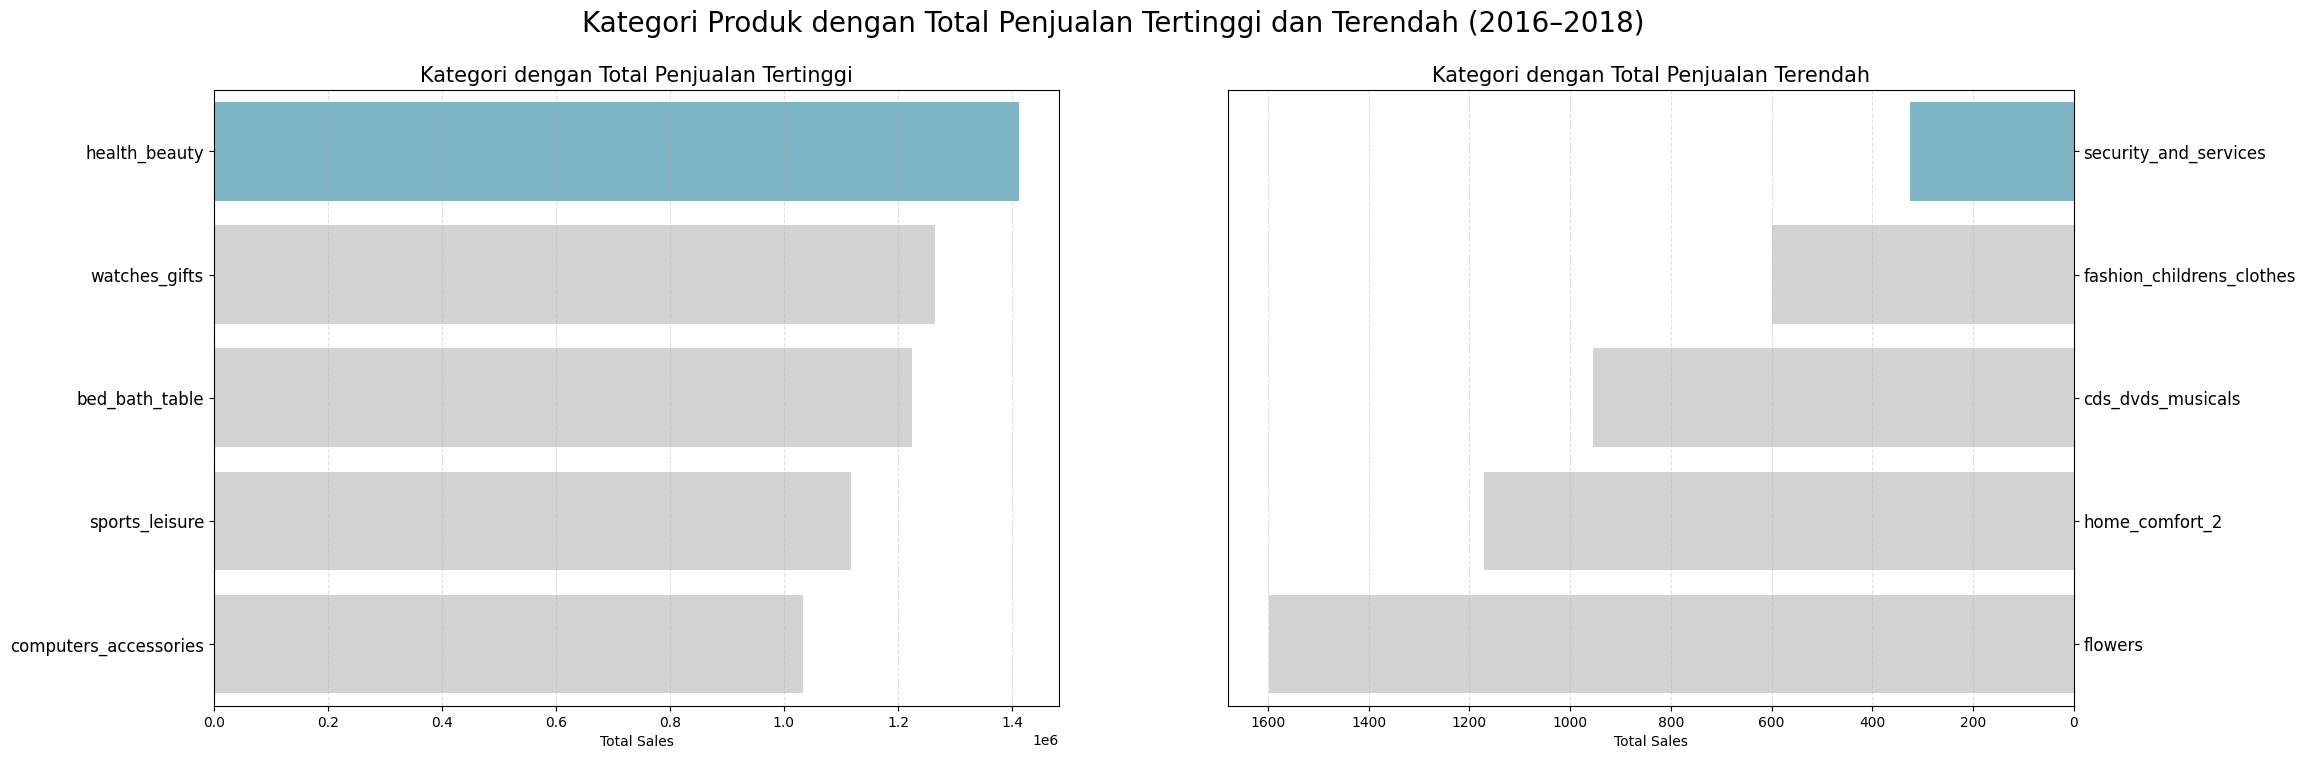

In [91]:
# Membuat dataframe kategori penjualan tertinggi
top_categories = category_sales.head(5).reset_index()

# Membuat dataframe kategori penjualan terendah
bottom_categories = category_sales.sort_values(ascending=True).head(5).reset_index()

# Membuat visualisasi
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(24, 8))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

# Grafik kategori dengan total penjualan tertinggi
sns.barplot(
    x="total_price",
    y="product_category_name_english",
    data=top_categories,
    hue="product_category_name_english",
    palette=colors,
    legend=False,
    ax=ax[0]
)

ax[0].set_ylabel(None)
ax[0].set_xlabel("Total Sales")
ax[0].set_title("Kategori dengan Total Penjualan Tertinggi", loc="center", fontsize=15)
ax[0].tick_params(axis='y', labelsize=12)

# Grafik kategori dengan total penjualan terendah
sns.barplot(
    x="total_price",
    y="product_category_name_english",
    data=bottom_categories,
    hue="product_category_name_english",
    palette=colors,
    legend=False,
    ax=ax[1]
)

ax[1].set_ylabel(None)
ax[1].set_xlabel("Total Sales")
ax[1].invert_xaxis()
ax[1].yaxis.set_label_position("right")
ax[1].yaxis.tick_right()
ax[1].set_title("Kategori dengan Total Penjualan Terendah", loc="center", fontsize=15)
ax[1].tick_params(axis='y', labelsize=12)
ax[0].grid(axis='x', linestyle='--', alpha=0.4)
ax[1].grid(axis='x', linestyle='--', alpha=0.4)

# Judul utama
plt.suptitle(
    "Kategori Produk dengan Total Penjualan Tertinggi dan Terendah (2016–2018)",
    fontsize=20
)

plt.show()

**Analisis Kategori Produk dengan Total Penjualan Tertinggi dan Terendah (2016–2018)**

Berdasarkan hasil analisis total penjualan kategori produk pada periode **2016–2018**, kategori `health_beauty` menjadi kategori dengan total penjualan tertinggi dengan nilai transaksi mencapai sekitar **1,41 juta BRL.** Selain itu, kategori lain seperti `watches_gifts` dan bed_bath_table juga menunjukkan performa penjualan yang tinggi dengan total transaksi masing-masing sekitar **1,26 juta BRL** dan **1,23 juta BRL**. Hal ini menunjukkan bahwa produk kebutuhan kecantikan, hadiah, dan perlengkapan rumah tangga memiliki permintaan yang tinggi selama periode tersebut.

Di sisi lain, kategori dengan total penjualan terendah adalah `security_and_services` dengan nilai transaksi hanya sekitar **324 BRL**, diikuti oleh `fashion_childrens_clothes` sekitar **599 BRL** dan `cds_dvds_musicals` sekitar **955 BRL**. Rendahnya nilai transaksi pada kategori tersebut menunjukkan bahwa permintaan pasar terhadap produk-produk tersebut relatif kecil dibandingkan kategori lainnya.

### Pertanyaan 2: Bagaimana tren total penjualan e-commerce setiap bulan selama periode 2016–2018?

In [92]:
# Membuat dataframe tren penjualan bulanan
monthly_sales_df = sales_df.resample(
    rule='ME',
    on='order_purchase_timestamp'
).agg({
    "total_price": "sum"
})

# Mengubah format tanggal menjadi Tahun-Bulan
monthly_sales_df.index = monthly_sales_df.index.strftime('%Y-%m')

# Reset index
monthly_sales_df = monthly_sales_df.reset_index()

# Mengubah nama kolom
monthly_sales_df.rename(columns={
    "order_purchase_timestamp": "month",
    "total_price": "total_sales"
}, inplace=True)

display(monthly_sales_df)

,month,total_sales
0,2016-09,143.46
1,2016-10,46490.66
2,2016-11,0.00
3,2016-12,19.62
4,2017-01,127482.37
5,2017-02,271239.32
6,2017-03,414330.95
7,2017-04,390812.40
8,2017-05,566851.40
9,2017-06,490050.37


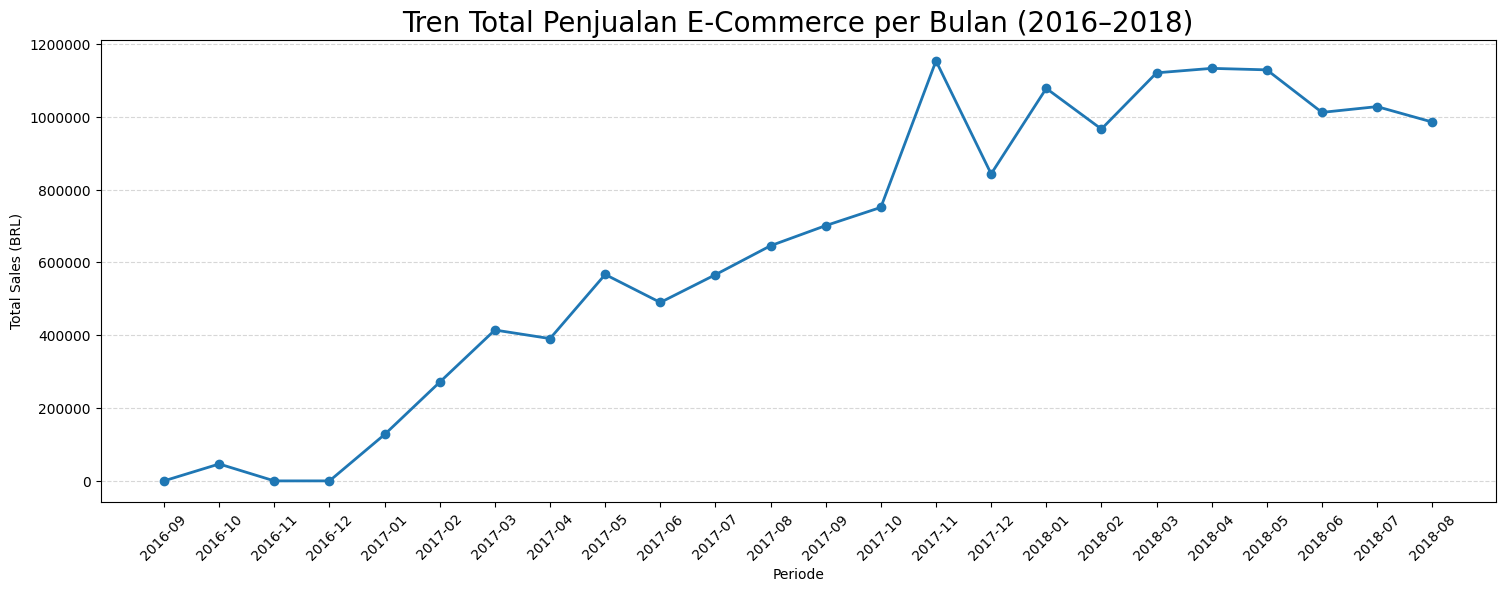

In [93]:
plt.figure(figsize=(18,6))

plt.plot(
    monthly_sales_df["month"],
    monthly_sales_df["total_sales"],
    marker='o',
    linewidth=2
)

plt.title(
    "Tren Total Penjualan E-Commerce per Bulan (2016–2018)",
    fontsize=20
)

plt.xticks(rotation=45)
plt.xlabel("Periode")
plt.ylabel("Total Sales (BRL)")
plt.ticklabel_format(style='plain', axis='y')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Analisis Tren Total Penjualan E-Commerce Bulanan (2016–2018)**

Berdasarkan visualisasi tren total penjualan e-commerce selama periode 2016–2018, terlihat bahwa penjualan mengalami peningkatan yang cukup signifikan dari waktu ke waktu. Pada awal periode, yaitu September hingga Desember 2016, total penjualan masih relatif rendah dan belum stabil. Namun, mulai Januari 2017 terjadi peningkatan penjualan secara bertahap dari sekitar **127 ribu BRL** hingga mencapai lebih dari **751 ribu BRL** pada Oktober 2017.

Puncak total penjualan terjadi pada bulan **November 2017** dengan nilai transaksi mencapai sekitar **1,15 juta BRL**. Meskipun sempat mengalami penurunan pada Desember 2017 menjadi sekitar **843 ribu BRL**, total penjualan kembali meningkat dan cenderung stabil sepanjang tahun 2018 pada kisaran **1 juta BRL** per bulan. Hal ini menunjukkan bahwa performa e-commerce mengalami pertumbuhan yang positif dan semakin stabil selama periode analisis.

#### **Insight:** (Opsional)


- Kategori `health_beauty` menjadi kategori dengan total penjualan tertinggi selama periode 2016–2018 dengan nilai transaksi mencapai lebih dari **1,4 juta BRL**, menunjukkan tingginya minat pelanggan terhadap produk kecantikan dan kesehatan.

- Tren total penjualan e-commerce mengalami peningkatan signifikan dari tahun 2016 hingga 2018, dengan puncak penjualan terjadi pada **November 2017** yang mencapai sekitar **1,15 juta BRL**.

## Analisis Lanjutan (Opsional)

## **RFM Analysis**

 RFM analysis merupakan salah satu metode yang umum digunakan untuk melakukan segmentasi pelanggan (mengelompokkan pelanggan ke dalam beberapa kategori) berdasarkan tiga parameter, yaitu recency, frequency, dan monetary.

 RFM analysis dilakukan untuk mengidentifikasi karakteristik dan perilaku pelanggan berdasarkan aktivitas transaksi mereka, dengan detail seperti berikut:

 - Recency: parameter yang digunakan untuk melihat kapan terakhir seorang pelanggan melakukan transaksi.
- Frequency: parameter ini digunakan untuk mengidentifikasi seberapa sering seorang pelanggan melakukan transaksi.
- Monetary: parameter terakhir ini digunakan untuk mengidentifikasi seberapa besar revenue yang berasal dari pelanggan tersebut.

In [94]:
# Membuat dataframe RFM
rfm_df = all_df.groupby(by="customer_id", as_index=False).agg({
    "order_purchase_timestamp": "max",  # mengambil tanggal order terakhir
    "order_id": "nunique",              # menghitung jumlah order
    "total_price": "sum"                # menghitung total revenue
})

# Mengubah nama kolom
rfm_df.columns = [
    "customer_id",
    "max_order_timestamp",
    "frequency",
    "monetary"
]

# Menghitung recency (selisih hari sejak transaksi terakhir)
recent_date = all_df["order_purchase_timestamp"].dt.date.max()

rfm_df["max_order_timestamp"] = rfm_df["max_order_timestamp"].dt.date

rfm_df["recency"] = rfm_df["max_order_timestamp"].apply(
    lambda x: (recent_date - x).days
)

# Menghapus kolom timestamp
rfm_df.drop("max_order_timestamp", axis=1, inplace=True)

# Menampilkan hasil
rfm_df.head()

,customer_id,frequency,monetary,recency
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,293
1,000161a058600d5901f007fab4c27140,1,67.41,414
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,552
3,0002414f95344307404f0ace7a26f1d5,1,179.35,383
4,000379cdec625522490c315e70c7a9fb,1,107.01,154


In [95]:
# Customer paling recent
print("Customer Paling Recent")
display(rfm_df.sort_values(by="recency", ascending=True).head())

# Customer paling sering belanja
print("Customer Paling Sering Berbelanja")
display(rfm_df.sort_values(by="frequency", ascending=False).head())

# Customer dengan total belanja terbesar
print("Customer dengan Total Belanja Terbesar")
display(rfm_df.sort_values(by="monetary", ascending=False).head())

Customer Paling Recent


,customer_id,frequency,monetary,recency
29063,4b7decb9b58e2569548b8b4c8e20e8d7,1,166.46,0
76152,c4c66f47534e09a03fc7a878a9eda5ea,1,74.21,5
71469,b8c19e70d00f6927388e4f31c923d785,1,178.25,5
42327,6e353700bc7bcdf6ebc15d6de16d7002,1,61.29,5
33320,56b1ac2855cc6d7950b4ffa6a9b41b0d,1,119.42,5


Customer Paling Sering Berbelanja


,customer_id,frequency,monetary,recency
98665,ffffa3172527f765de70084a7e53aae8,1,45.50,366
0,00012a2ce6f8dcda20d059ce98491703,1,114.74,293
1,000161a058600d5901f007fab4c27140,1,67.41,414
2,0001fd6190edaaf884bcaf3d49edf079,1,195.42,552
3,0002414f95344307404f0ace7a26f1d5,1,179.35,383


Customer dengan Total Belanja Terbesar


,customer_id,frequency,monetary,recency
8475,1617b1357756262bfa56ab541c47bc16,1,13664.08,339
91284,ec5b2ba62e574342386871631fafd3fc,1,7274.88,50
76948,c6e2731c5b391845f6800c97401a43a9,1,6929.31,568
94398,f48d464a0baaea338cb25f816991ab1f,1,6922.21,40
24603,3fd6777bbce08a352fddd04e4a7cc8f6,1,6726.66,467


/tmp/ipykernel_5855/2415815748.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


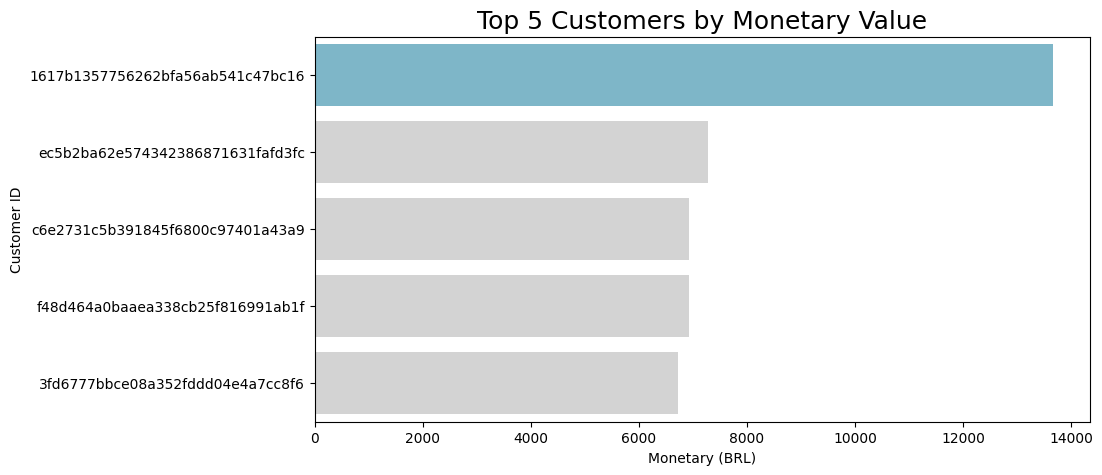

In [96]:
# Mengurutkan customer berdasarkan monetary tertinggi
top_monetary = rfm_df.sort_values(by="monetary", ascending=False).head(5)

# Membuat visualisasi
plt.figure(figsize=(10, 5))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="monetary",
    y="customer_id",
    data=top_monetary,
    palette=colors
)

plt.title("Top 5 Customers by Monetary Value", fontsize=18)
plt.xlabel("Monetary (BRL)")
plt.ylabel("Customer ID")

plt.show()

/tmp/ipykernel_5855/3669446768.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


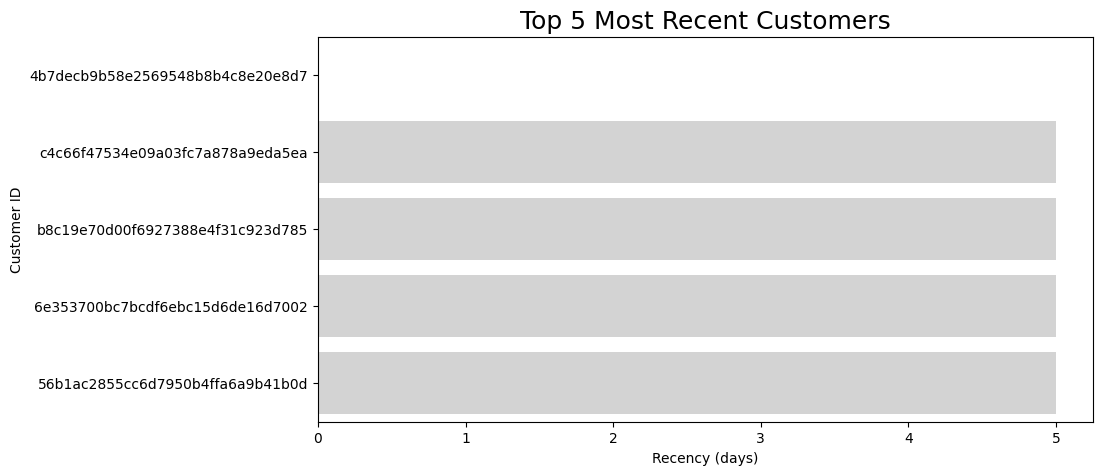

In [97]:
# Mengurutkan customer berdasarkan recency terendah
# (semakin kecil recency, semakin baru customer bertransaksi)
top_recency = rfm_df.sort_values(by="recency", ascending=True).head(5)

# Membuat visualisasi
plt.figure(figsize=(10, 5))

colors = ["#72BCD4", "#D3D3D3", "#D3D3D3", "#D3D3D3", "#D3D3D3"]

sns.barplot(
    x="recency",
    y="customer_id",
    data=top_recency,
    palette=colors
)

plt.title("Top 5 Most Recent Customers", fontsize=18)
plt.xlabel("Recency (days)")
plt.ylabel("Customer ID")

plt.show()

#### **Insight:** (Opsional)
- Customer paling recent memiliki nilai recency sebesar **0 hari**, yang menunjukkan bahwa customer tersebut masih aktif melakukan transaksi hingga akhir periode analisis. Selain itu, beberapa customer lainnya juga memiliki recency rendah, yaitu sekitar **5 hari**, sehingga berpotensi menjadi pelanggan loyal.

- Customer dengan nilai monetary tertinggi memiliki total transaksi mencapai sekitar **13.664 BRL**, jauh lebih tinggi dibandingkan customer lainnya. Namun, sebagian besar customer memiliki nilai frequency sebesar **1**, yang menunjukkan bahwa mayoritas pelanggan hanya melakukan satu kali transaksi selama periode analisis.

## Conclusion & Recommendation

- Conclusion pertanyaan 1: Kategori produk `health_beauty` menjadi kategori dengan total penjualan tertinggi selama periode 2016–2018 dengan nilai transaksi mencapai lebih dari **1,4 juta BRL**. Sebaliknya, kategori `security_and_services` memiliki total penjualan terendah dengan nilai transaksi sekitar **324 BRL**.

- Conclusion pertanyaan 2: Tren total penjualan e-commerce menunjukkan peningkatan yang signifikan dari tahun 2016 hingga 2018. Puncak penjualan terjadi pada **November 2017** dengan total transaksi mencapai sekitar **1,15 juta BRL**, sementara sepanjang tahun 2018 penjualan cenderung stabil pada kisaran lebih dari **1 juta BRL** per bulan.



**Rekomendasi Action Item:**

- Perusahaan dapat meningkatkan promosi dan mempertahankan strategi pemasaran pada kategori dengan performa penjualan tinggi seperti **health_beauty** dan **watches_gifts** karena kategori tersebut memberikan kontribusi revenue terbesar selama periode analisis.

- Perusahaan dapat melakukan evaluasi terhadap kategori dengan penjualan rendah seperti **security_and_services** dan **fashion_childrens_clothes** melalui strategi promosi, bundling produk, atau analisis kebutuhan pelanggan untuk meningkatkan minat pembelian.

## Menyimpan Berkas Data

In [98]:
all_df.to_csv("all_data_submission.csv", index=False)